In [1]:
import os
import shutil
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import distance_transform_edt, gaussian_filter
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from skimage.io import imshow
from sklearn.decomposition import PCA
from skimage import measure
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.neighbors import KDTree

In [2]:
# Loads a grayscale image, binarizes it, and centers it in an SxS canvas with zero-padding
def pad_binary(path, S):
    img = np.array(Image.open(path).convert("L"))
    binary = (img > 127).astype(np.uint8)
    h, w = binary.shape
    if h > S or w > S:
        raise ValueError(f"Image ({h},{w}) is larger than target size S={S}")
    pad_top    = (S - h) // 2
    pad_bottom = S - h - pad_top
    pad_left   = (S - w) // 2
    pad_right  = S - w - pad_left
    padded = np.pad(binary,((pad_top, pad_bottom), (pad_left, pad_right)),mode='constant',constant_values=0)
    return padded

# Creates an SxS grid of (x, y) coordinates ranging from -1 to 1
def make_square_grid(S):
    xs = np.linspace(-1, 1, S)
    ys = np.linspace(-1, 1, S)
    X, Y = np.meshgrid(xs, ys)
    coords = np.stack([X, Y], axis=-1)   # (S, S, 2)
    return coords

# Flips the image vertically (to match grid orientation) and appends it as a third channel to the grid
def move_image_to_grid(set_grid, img):
    img_flipped = img[::-1, :]
    return np.concatenate([set_grid, img_flipped[..., None].astype(np.uint8)], axis=-1)

# Extracts only the "on" pixels (value > 0) and returns their (x, y) coordinates
def get_shape(bin):
    return bin[bin[:, :, 2] > 0][:, :2]

# Returns the number of "on" pixels as the shape's volume
def compute_volume(shape):
    return float(shape.shape[0])

# Computes the centroid
def compute_centroid(shape):
    V = compute_volume(shape)
    sum_x = shape[:, 0].sum()
    sum_y = shape[:, 1].sum()
    center = np.array([sum_x / V, sum_y / V])
    return center

# Computes the 2x2 covariance matrix
def compute_covariance(shape):
    V = compute_volume(shape)
    beta = compute_centroid(shape)
    coords_shift=shape-beta
    cov_mat=(coords_shift.T @ coords_shift) / V
    return cov_mat

# Returns the size of the shape as the square root of the covariance matrix's trace
def compute_size(shape):
    return float(np.sqrt(np.trace(compute_covariance(shape))))

# Computes the alignment transform (scale λ, rotation R, translation t)
# that normalizes the shape to a target size and orients it along its principal axes
def compute_alignment(shape,target_size=0.4, flip=(-1,-1)):
    beta = compute_centroid(shape)
    gamma = compute_size(shape)
    lam = target_size / gamma
    _, V = np.linalg.eigh(compute_covariance(shape))
    V = V[:, [1, 0]]
    V[:, 0] *= flip[0]
    V[:, 1] *= flip[1]
    R = V.T
    t = -lam * (R @ beta)
    return lam, R, t

def transform_on_set_grid(set_grid, img, lam, R, t):
    Ycoords = set_grid.reshape(-1, 2)
    # Map each output grid point back to source image coordinates via inverse transform
    Xquery = ((Ycoords - t) @ R) / lam
    src_coords = img[:, :, :2].reshape(-1, 2)
    src_vals   = img[:, :, 2].reshape(-1)
    # Nearest-neighbor lookup: find the closest source pixel for each transformed query point
    tree = KDTree(src_coords)
    _, idx = tree.query(Xquery, k=1)
    idx = idx[:, 0]
    sampled_vals = src_vals[idx]
    out = np.concatenate([Ycoords, sampled_vals[:, None]], axis=1)
    return out.reshape(S, S, 3)

# Constructs a similarity transform (scale, rotation, translation) from explicit parameters
def make_g(lam, angle, t):
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ], dtype=np.float32)
    t = np.array(t, dtype=np.float32)
    return float(lam), R, t

# Inverts a similarity transform to get the reverse mapping
def invert_g(lam, R, t):
    lam_inv = 1.0 / lam
    R_inv = R.T
    t_inv = -(t @ R) / lam
    return lam_inv, R_inv, t_inv

# Extracts and prints the scalar angle and translation from a rotation matrix
def g_to_lam_angle_t(lam, R, te):
  angle = np.arctan2(R[1, 0], R[0, 0])
  print(f"lam   = {lam:.8f}")
  print(f"angle = {angle:.8f}")
  print(f"t     = [{t[0]:.8f}, {t[1]:.8f}]")
  return lam, angle, t


In [3]:
# Computes the signed distance field (SDF) of a binary shape
def compute_sdf(bin, root=None):
    coords = bin[:, :, :2]
    vals = bin[:, :, 2].copy()
    if root is not None:
        xcoords = coords[:, :, 0]
        vals[xcoords < root] = 0
    mask = vals > 0
    d = 2.0 / (S - 1)
    dist_out = distance_transform_edt(~mask, sampling=(d, d))
    dist_in  = distance_transform_edt(mask,  sampling=(d, d))
    sdf = dist_out - dist_in
    sdf_bin = np.concatenate([coords, sdf[..., None]], axis=-1)
    return sdf_bin

# Retrieves the latent code vector for a given shape index
def get_z(latent_codes, shape_idx):
    shape_idx = torch.tensor([shape_idx], dtype=torch.long).to(device)
    z = latent_codes(shape_idx)
    return z

# Runs the model over the full grid to produce a predicted SDF image for a given latent code
def predicted_sdf(model, z, set_grid):
    model.eval()
    coords_np = set_grid.reshape(-1, 2)
    coords = torch.tensor(coords_np, dtype=torch.float32).to(device)
    if z.dim() == 1:
        z = z.unsqueeze(0)
    z = z.to(device)
    z_rep = z.repeat(coords.shape[0], 1)
    with torch.no_grad():
        pred_vals = model(z_rep, coords)
    pred_vals = pred_vals.squeeze().cpu().numpy()
    pred_sdf_flat = np.concatenate([coords_np, pred_vals[:, None]],axis=1)
    pred_sdf = pred_sdf_flat.reshape(S, S, 3)
    return pred_sdf

# Same as predicted_sdf but applies a similarity transform to map grid coords
# back to model space before querying — used when g is known from optimization
def predicted_sdf_transformed(model, z, set_grid, lam, R, t):
    model.eval()
    Ycoords = set_grid.reshape(-1, 2)
    Xquery = ((Ycoords - t) @ R) / lam
    coords = torch.tensor(Xquery, dtype=torch.float32).to(device)
    if z.dim() == 1:
        z = z.unsqueeze(0)
    z = z.to(device)
    z_rep = z.repeat(coords.shape[0], 1)
    with torch.no_grad():
        pred_vals = model(z_rep, coords)
    pred_vals = pred_vals.squeeze().cpu().numpy()
    out_flat = np.concatenate([Ycoords, pred_vals[:, None]], axis=1)
    H, W = set_grid.shape[:2]
    return out_flat.reshape(H, W, 3)

# Inverts a similarity transform to get the reverse mapping
def invert_g(lam, R, t):
    lam_inv = 1.0 / lam
    R_inv = R.T
    t_inv = -lam_inv * (R_inv @ t)
    return lam_inv, R_inv, t_inv

# Smooth approximation of the Heaviside step function using sigmoid
def smooth_heaviside(sdf, eps=0.01):
    return 1.0 / (1.0 + np.exp(sdf / eps))

# Converts a full SDF grid to a smooth characteristic (indicator) field
def sdf_to_characteristic(sdf_grid, eps=0.01):
    Z = sdf_grid[:, :, 2]
    chi = smooth_heaviside(Z, eps=eps)
    out = np.concatenate([sdf_grid[:, :, :2], chi[:, :, None]],axis=-1)
    return out

In [4]:
# Load the trained model and latent codes from checkpoint
# and move them to the available device
from my_siren_model import load_trained_model

model, latent_codes, device = load_trained_model(checkpoint_path='final_model.pth',num_wings=199,latent_dim=16)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)
latent_codes = latent_codes.to(device)
model.eval()

print("Model device:", next(model.parameters()).device)
print("Latent device:", latent_codes.weight.device)

Using device: cuda
Model device: cuda:0
Latent device: cuda:0


In [5]:
# Compute nearest-neighbor distances across all learned latent
# codes to understand how densely the latent space is populated

Z_all = latent_codes.weight.detach()

# pairwise distances between all training latents
dists_all = torch.cdist(Z_all, Z_all)

# exclude self-distances (diagonal)
dists_all.fill_diagonal_(float('inf'))

# nearest neighbor distance for each latent
nearest_dists = dists_all.min(dim=1).values

print(f"mean nearest-neighbor distance:   {nearest_dists.mean():.4f}")
print(f"median nearest-neighbor distance: {nearest_dists.median():.4f}")
print(f"min nearest-neighbor distance:    {nearest_dists.min():.4f}")
print(f"max nearest-neighbor distance:    {nearest_dists.max():.4f}")

mean nearest-neighbor distance:   0.0029
median nearest-neighbor distance: 0.0028
min nearest-neighbor distance:    0.0007
max nearest-neighbor distance:    0.0071


In [6]:
from sklearn.cluster import KMeans
import numpy as np
# Cluster all latent codes with KMeans and return the index of the real
# sample closest to each centroid — useful for picking diverse shape representatives

def get_cluster_representatives(Z_all, n_clusters=10):
    Z_np = Z_all.detach().cpu().numpy()

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans.fit(Z_np)

    centroids = kmeans.cluster_centers_  # (n_clusters, latent_dim)

    # For each centroid, find the closest real z in Z_all
    representative_indices = []
    for centroid in centroids:
        dists = np.linalg.norm(Z_np - centroid, axis=1)
        representative_indices.append(np.argmin(dists))

    return representative_indices  # list of indices into Z_all

Z_all = latent_codes.weight.detach()
rep_indices = get_cluster_representatives(Z_all, n_clusters=25)
print(rep_indices)

[np.int64(159), np.int64(191), np.int64(10), np.int64(45), np.int64(103), np.int64(76), np.int64(87), np.int64(37), np.int64(133), np.int64(54), np.int64(110), np.int64(119), np.int64(83), np.int64(142), np.int64(197), np.int64(41), np.int64(173), np.int64(121), np.int64(152), np.int64(96), np.int64(4), np.int64(183), np.int64(109), np.int64(124), np.int64(180)]


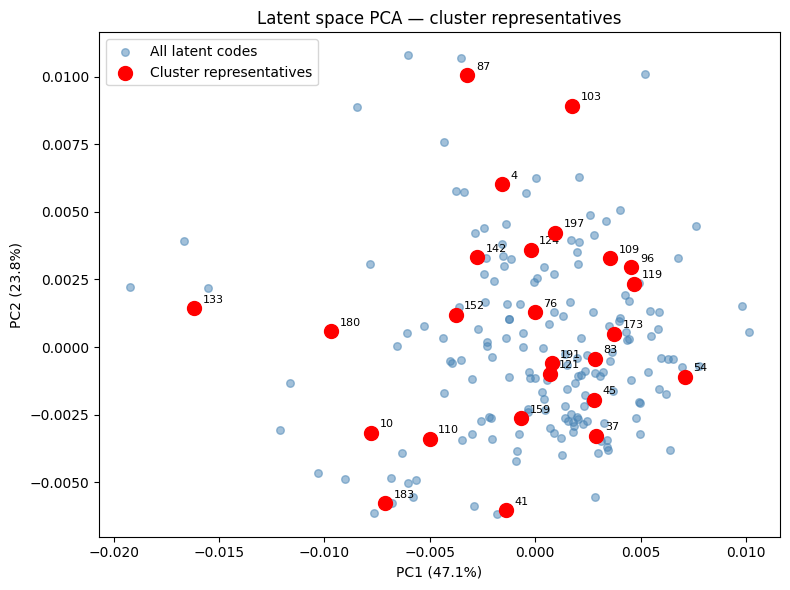

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_clusters_on_pca(Z_all, rep_indices, n_components=2):
    Z_np = Z_all.detach().cpu().numpy()

    pca = PCA(n_components=n_components)
    Z_pca = pca.fit_transform(Z_np)
    rep_pca = Z_pca[rep_indices]
    plt.figure(figsize=(8, 6))
    plt.scatter(Z_pca[:, 0], Z_pca[:, 1], c='steelblue', alpha=0.5, s=30, label='All latent codes')
    plt.scatter(rep_pca[:, 0], rep_pca[:, 1], c='red', s=100, zorder=5, label='Cluster representatives')
    for idx, (x, y) in zip(rep_indices, rep_pca):
        plt.annotate(str(idx), (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('Latent space PCA — cluster representatives')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_clusters_on_pca(Z_all, rep_indices)

In [9]:
# Plots the target shape vs current predicted shape overlaying both contours
# using smooth Heaviside fields — blue for target, red for current
def plot_current_characteristic(model, z, set_grid, chi_y, log_lam, angle, t, device, step, eps_chi=0.005):
    H, W = set_grid.shape[:2]
    coords = torch.tensor(set_grid.reshape(-1, 2),dtype=torch.float32,device=device)
    with torch.no_grad():
        sdf_current, _ = predicted_sdf_transformed_torch(model=model,z=z,coords=coords,log_lam=log_lam,angle=angle,t=t)
    chi_current = np.zeros((H, W, 3), dtype=np.float32)
    chi_current[:, :, 0] = set_grid[:, :, 0]
    chi_current[:, :, 1] = set_grid[:, :, 1]
    chi_current[:, :, 2] = torch_smooth_heaviside(sdf_current.reshape(H, W),eps=eps_chi).detach().cpu().numpy()
    X = chi_y[:, :, 0]
    Y = chi_y[:, :, 1]
    C1 = chi_y[:, :, 2]
    C2 = chi_current[:, :, 2]
    plt.figure(figsize=(7, 7))
    plt.imshow(C1, extent=[X.min(), X.max(), Y.min(), Y.max()], origin="lower", alpha=0.5, vmin=0, vmax=1)
    plt.imshow(C2, extent=[X.min(), X.max(), Y.min(), Y.max()], origin="lower", alpha=0.5, vmin=0, vmax=1)
    plt.contour(X, Y, C1, levels=[0.5], colors="blue", linewidths=2)
    plt.contour(X, Y, C2, levels=[0.5], colors="red", linewidths=2)
    plt.scatter([0], [0], color="black", s=25)
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.gca().set_aspect("equal")
    plt.title(f"target y vs current prediction | step {step}")
    plt.show()

# Projects the current latent z onto the 2D PCA of training latents and plots
# it alongside all training codes
def plot_current_latent_pca(latent_codes, z, init_shape_idx, step):
    with torch.no_grad():
        Z = latent_codes.weight.detach().cpu().numpy()
        z_np = z.detach().cpu().numpy()
    if z_np.ndim == 1:
        z_np = z_np[None, :]
    pca = PCA(n_components=2)
    Z_2d = pca.fit_transform(Z)
    z_2d = pca.transform(z_np)
    plt.figure(figsize=(8, 8))
    plt.scatter(Z_2d[:, 0], Z_2d[:, 1], color="red", alpha=0.8, label="training latents")
    for idx, (x, y) in enumerate(Z_2d):
        plt.text(x, y, str(idx), fontsize=8)
    plt.scatter(Z_2d[init_shape_idx, 0],Z_2d[init_shape_idx, 1],color="green",s=180,edgecolors="black",label="initial latent")
    plt.scatter(z_2d[:, 0],z_2d[:, 1],color="blue",s=220,edgecolors="black",label="current optimized theta")
    plt.title(f"PCA latent space | step {step}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

# Soft-projects z toward the nearest training latents using
# temperature-scaled softmax weights
def project_to_convex_hull(z, Z_all):
    dists = torch.sum((Z_all - z) ** 2, dim=1)  # (N,)
    w = torch.softmax(-dists / 0.1, dim=0)       # temperature 0.1 = sharp
    z_proj = (w[:, None] * Z_all).sum(dim=0, keepdim=True)
    return z_proj

# Smooth approximation of the Heaviside step function using sigmoid
def torch_smooth_heaviside(sdf, eps=0.01):
    return torch.sigmoid(-sdf / eps)

# Gaussian-weighted Parzen window approximation of the Dirac delta (surface indicator)
def torch_parzen_dirac(sdf, sigma=0.03, normalize=True):
    w = torch.exp(-0.5 * (sdf / sigma) ** 2)
    if normalize:
        w = w / (w.mean() + 1e-8)
    return w

# Returns a binary weight mask that zeros out points left of the root region (wing root crop)
def root_region_weight_from_Xquery(Xquery, root_x=-0.7, root_margin=0.08):
    x = Xquery[:, 0]
    weights = torch.ones_like(x)
    weights[x < root_x + root_margin] = 0.0
    return weights

# Applies the inverse similarity transform to map output grid coords back to
# model space, then queries the model
def predicted_sdf_transformed_torch(model, z, coords, log_lam, angle, t):
    lam = torch.exp(log_lam)
    c = torch.cos(angle)
    s = torch.sin(angle)
    R = torch.stack([torch.stack([c, -s]),torch.stack([s,  c])])
    Xquery = ((coords - t) @ R) / lam
    z_rep = z.repeat(coords.shape[0], 1)
    sdf_vals = model(z_rep, Xquery).squeeze()
    return sdf_vals, Xquery

# Computes log-likelihood of z under a Parzen window density estimated from all training latents
def parzen_log_density(z, Z_all, sigma=1.0):
    dists_sq = torch.sum((Z_all - z) ** 2, dim=1)
    log_kernels = -dists_sq / (2 * sigma ** 2)
    log_p = torch.logsumexp(log_kernels, dim=0)
    return log_p

# Weighted data loss focused on the contour band, comparing predicted and target Heaviside fields
def contour_band_data_loss(chi_y, sdf_pred, root_mask, eps=0.03, p=2, band_sigma=0.03):
    contour_weights = torch.exp(-0.5 * (sdf_pred / band_sigma) ** 2)
    weights = contour_weights * root_mask
    weights_sum = weights.sum() + 1e-8
    chi_pred = torch_smooth_heaviside(sdf_pred, eps=eps)
    point_loss = torch.abs(chi_y - chi_pred) ** p
    loss = (1.0 / p) * torch.sum(weights * point_loss) / weights_sum
    return loss

# Upweights a specific x-range region in query space (used to emphasize the root attachment area)
def right_region_weight(Xquery, x_min=-0.8, x_max=-0.4):
    x = Xquery[:, 0]
    weights = torch.ones_like(x)
    weights[(x >= x_min) & (x <= x_max)] = 10.0
    return weights


In [10]:
# OPTIMIZATION FUNCTION
# Phase 1: sweeps over candidate latents with short g-only optimization to find
# the best initialization
# Phase 2: jointly optimizes the similarity transform g and latent z with a Parzen
# regularizer to fit the target shape

def optimize_theta_and_g(
    model,
    latent_codes,
    rep_indices,
    set_grid,
    sdf_y,
    device,
    eps=0.005,
    p=2,
    mu=1e-3,
    sigma=0.001,
    steps=500,
    lr_g=1e-2,
    lr_z=1e-4,
    root_x=-0.78,
    root_margin=0.00,
    band_sigma=0.07,
    region_x_min=-0.78,
    region_x_max=-0.4,
    region_weight=10.0,
    pre_steps=50,):
    model.eval()
    for param in model.parameters():
        param.requires_grad_(False)
    coords = torch.tensor(set_grid.reshape(-1, 2), dtype=torch.float32, device=device)
    sdf_y_np = sdf_y[:, :, 2] if sdf_y.ndim == 3 else sdf_y
    sdf_y_torch = torch.tensor(sdf_y_np.reshape(-1), dtype=torch.float32, device=device)
    chi_y = torch_smooth_heaviside(sdf_y_torch, eps=eps)
    #inside_weight =  chi_y  # inside~1.5, outside~1.0

    outside_penalty = 0.1
    inside_weight = chi_y + outside_penalty * (1.0 - chi_y)


    Z_all = latent_codes.weight.detach().to(device)

    def run_short_g_optim(z_candidate):
        z_fixed = z_candidate.clone().detach()  # frozen, no grad
        _log_lam = torch.tensor(0.0,        dtype=torch.float32, device=device, requires_grad=True)
        _angle   = torch.tensor(0.0,        dtype=torch.float32, device=device, requires_grad=True)
        _t       = torch.tensor([0.0, 0.0], dtype=torch.float32, device=device, requires_grad=True)
        _optimizer = torch.optim.Adam([_log_lam, _angle, _t], lr=lr_g)
        for _ in range(pre_steps):
            _optimizer.zero_grad()
            sdf_pred, Xquery = predicted_sdf_transformed_torch(
                model=model, z=z_fixed, coords=coords,
                log_lam=_log_lam, angle=_angle, t=_t)
            chi_pred = torch_smooth_heaviside(sdf_pred, eps=eps)
            root_mask      = root_region_weight_from_Xquery(Xquery=Xquery, root_x=root_x, root_margin=root_margin)
            region_weights = torch.ones_like(sdf_pred)
            x_query        = Xquery[:, 0]
            region_weights[(x_query >= region_x_min) & (x_query <= region_x_max)] = region_weight
            weights     = root_mask * region_weights * inside_weight
            weights_sum = weights.sum() + 1e-8
            point_loss  = torch.abs(chi_y - chi_pred) ** p
            data_loss   = (1.0 / p) * torch.sum(weights * point_loss) / weights_sum
            if torch.isnan(data_loss):
                break
            data_loss.backward()
            torch.nn.utils.clip_grad_norm_([_log_lam, _angle, _t], max_norm=1.0)
            _optimizer.step()
            with torch.no_grad():
                _log_lam.clamp_(np.log(0.3), np.log(3.0))
                _t.clamp_(-1.0, 1.0)
        return data_loss.item(), _log_lam.detach(), _angle.detach(), _t.detach()

    print(f"--- Coarse sweep over {len(rep_indices)} candidates ({pre_steps} steps each) ---")
    best_sweep_loss = float('inf')
    best_z_init     = None
    best_log_lam    = None
    best_angle      = None
    best_t          = None
    for idx in rep_indices:
        z_candidate = Z_all[idx].unsqueeze(0).clone()
        sweep_loss, _log_lam, _angle, _t = run_short_g_optim(z_candidate)
        print(f"  candidate idx={idx:3d} | sweep_loss={sweep_loss:.6f}")
        if sweep_loss < best_sweep_loss:
            best_sweep_loss = sweep_loss
            best_rep_idx    = idx
            best_z_init     = z_candidate
            best_log_lam    = _log_lam.clone()
            best_angle      = _angle.clone()
            best_t          = _t.clone()
    print(f"--- Best candidate loss={best_sweep_loss:.6f} ---")
    #  PHASE 2
    z0 = best_z_init.clone().detach()
    z  = z0.clone().detach().requires_grad_(True)
    log_lam = best_log_lam.clone().requires_grad_(True)
    angle   = best_angle.clone().requires_grad_(True)
    t       = best_t.clone().requires_grad_(True)
    optimizer_g = torch.optim.Adam([
        {"params": [log_lam, angle, t], "lr": lr_g},])
    losses      = []
    data_losses = []
    reg_losses  = []
    best_loss     = float('inf')
    best_snapshot = None
    for step in range(steps):
        optimizer_g.zero_grad()
        if z.grad is not None:
            z.grad.zero_()
        sdf_pred, Xquery = predicted_sdf_transformed_torch(
            model=model, z=z, coords=coords,
            log_lam=log_lam, angle=angle, t=t)
        chi_pred = torch_smooth_heaviside(sdf_pred, eps=eps)
        root_mask      = root_region_weight_from_Xquery(Xquery=Xquery, root_x=root_x, root_margin=root_margin)
        region_weights = torch.ones_like(sdf_pred)
        x_query        = Xquery[:, 0]
        region_weights[(x_query >= region_x_min) & (x_query <= region_x_max)] = region_weight
        #weights     = root_mask * region_weights
        #weights_sum = weights.sum() + 1e-8

        weights     = root_mask * region_weights * inside_weight
        weights_sum = weights.sum() + 1e-8
        point_loss  = torch.abs(chi_y - chi_pred) ** p
        data_loss   = (1.0 / p) * torch.sum(weights * point_loss) / weights_sum
        dists_sq = torch.sum((Z_all - z) ** 2, dim=1)
        min_dist = dists_sq.min()

        if min_dist > sigma ** 2:
            reg_loss = -mu * parzen_log_density(z, Z_all, sigma=sigma)
        else:
            reg_loss = torch.tensor(0.0, device=device)

        loss = data_loss + reg_loss

        if torch.isnan(loss):
            print(f"NaN at step {step}")
            break

        loss.backward()
        torch.nn.utils.clip_grad_norm_([log_lam, angle, t], max_norm=1.0)
        optimizer_g.step()
        with torch.no_grad():
            if z.grad is not None:
                z -= lr_z * z.grad
            log_lam.clamp_(np.log(0.3), np.log(3.0))
            t.clamp_(-1.0, 1.0)

        # --- best snapshot ---
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_snapshot = {
                "loss":    loss.item(),
                "lam":     torch.exp(log_lam).detach().cpu().item(),
                "angle":   angle.detach().cpu().item(),
                "t":       t.detach().cpu().numpy().copy(),
                "z":       z.detach().cpu().clone(),}

        losses.append(loss.item())
        data_losses.append(data_loss.item())
        reg_losses.append(reg_loss.item() if isinstance(reg_loss, torch.Tensor) else reg_loss)

        if step % 50 == 0:
            z_change    = torch.norm(z - z0).item()
            z_grad_norm = z.grad.norm().item() if z.grad is not None else 0.0
            print(
                f"step {step:04d} | loss={loss.item():.6f} | "
                f"data={data_loss.item():.6f} | "
                f"reg={reg_loss.item() if isinstance(reg_loss, torch.Tensor) else reg_loss:.6f} | "
                f"z_change={z_change:.4f} | "
                f"z_grad={z_grad_norm:.6f} | "
                f"lam={torch.exp(log_lam).item():.4f} | "
                f"angle={angle.item():.4f} | "
                f"t=[{t[0].item():.4f}, {t[1].item():.4f}]"
            )
            chi_y_grid = np.concatenate([
                set_grid[:, :, :2],
                chi_y.reshape(set_grid.shape[:2]).detach().cpu().numpy()[:, :, None]
            ], axis=-1)
            if step % 250 == 0:
                plot_current_characteristic(
                    model=model, z=z, set_grid=set_grid, chi_y=chi_y_grid,
                    log_lam=log_lam, angle=angle, t=t, device=device, step=step
                )
                plot_current_latent_pca(
                    latent_codes=latent_codes, z=z,
                    init_shape_idx=best_rep_idx, step=step
                )

    return {
        "loss":        best_snapshot["loss"],
        "lam":         best_snapshot["lam"],
        "angle":       best_snapshot["angle"],
        "t":           best_snapshot["t"],
        "z_optimized": best_snapshot["z"],
        "z_initial":       z0.detach().cpu(),
        "losses":          losses,
        "data_losses":     data_losses,
        "reg_losses":      reg_losses,
        "best_sweep_loss": best_sweep_loss,
        "rep_indices":     rep_indices,
    }

In [ ]:
# Load target image, compute its SDF, then run the full optimization to find
# the best latent code and similarity transform that reconstruct the shape
S=1001
set_grid = make_square_grid(S)
image    = 'rec_16.png' # LOAD IMAGE HERE
pad      = pad_binary(image, S)
y        = move_image_to_grid(set_grid, pad)
y_sdf    = compute_sdf(y)

results = optimize_theta_and_g(
    model=model,
    latent_codes=latent_codes,
    rep_indices=rep_indices,
    set_grid=set_grid,
    sdf_y=y_sdf,
    device=device,
    steps=1500,
    pre_steps=50,
    lr_g=1e-2,
    lr_z=1e-4,
)

print(f"Best loss:  {results['loss']:.6f}")
print(f"Best lam:   {results['lam']:.4f}")
print(f"Best angle: {results['angle']:.4f}")
print(f"Best t:     {results['t']}")
print(f"Best z:     {results['z_optimized'].shape}")

In [12]:
# PLOTTING
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_final_match_and_latent(
    model,
    latent_codes,
    set_grid,
    y_sdf,
    results,
    device,
    found_label="optimized latent code",
):
    """
    Left:
        Damaged observed shape shown by its characteristic function,
        together with the zero-level contour of the optimized transformed shape.

    Right:
        PCA projection of the learned latent space, including coordinates and grid.
    """

    # ---------- read optimized result ----------
    z_found = results["z_optimized"].to(device)

    if z_found.dim() == 1:
        z_found = z_found.unsqueeze(0)

    lam = results["lam"]
    angle = results["angle"]
    t = np.array(results["t"], dtype=np.float32)

    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s],
                  [s,  c]], dtype=np.float32)

    # ---------- transformed prediction ----------
    pred_sdf = predicted_sdf_transformed(
        model=model,
        z=z_found,
        set_grid=set_grid,
        lam=lam,
        R=R,
        t=t,
    )

    # ---------- PCA latent space ----------
    with torch.no_grad():
        Z = latent_codes.weight.detach().cpu().numpy()
        z_np = z_found.detach().cpu().numpy()

    pca = PCA(n_components=2)
    Z2 = pca.fit_transform(Z)
    z2 = pca.transform(z_np)

    explained = pca.explained_variance_ratio_ * 100

    # ---------- plotting ----------
    fig = plt.figure(figsize=(16, 7), dpi=130, facecolor="white")
    gs = plt.GridSpec(1, 2, figure=fig, wspace=0.18)

    ax_l = fig.add_subplot(gs[0, 0])
    ax_r = fig.add_subplot(gs[0, 1])

    X = set_grid[:, :, 0]
    Y = set_grid[:, :, 1]

    # ============================================================
    # LEFT: observed characteristic function + reconstructed contour
    # ============================================================

 # ===== LEFT: only damaged wing + optimized contour =====
    chi_y = (y_sdf[:, :, 2] <= 0).astype(float)

    ax_l.pcolormesh(X, Y, chi_y, shading="auto", cmap="Greys", alpha=0.85,)

    ax_l.contour(X, Y, pred_sdf[:, :, 2],levels=[0],colors=["#e03030"],linewidths=4,)
    ax_l.text(0.03,0.97,rf"$g^\ast$: scale={lam:.3f}, angle={angle:.3f}, t=({t[0]:.3f},{t[1]:.3f})",transform=ax_l.transAxes,ha="left",va="top",fontsize=10,bbox=dict(boxstyle="round,pad=0.35",facecolor="white",edgecolor="none",alpha=0.85))
    ax_l.legend(handles=[Patch(facecolor="black",edgecolor="black",label="Observed damaged shape"),Line2D([0],[0],color="#e03030",lw=4,label="Optimized reconstruction boundary")],loc="lower right",frameon=False,fontsize=11)
    ax_l.set_xticks([]); ax_l.set_yticks([])
    for spine in ax_l.spines.values():
        spine.set_visible(False)

    # ============================================================
    # RIGHT: latent PCA with coordinates and grid
    # ============================================================

    ax_r.scatter(
        Z2[:, 0], Z2[:, 1],
        s=75,
        color="#222222",
        edgecolors="white",
        linewidths=0.6,
        alpha=0.85,
        zorder=2,
        label="Training latent codes",
    )

    ax_r.scatter(
        z2[0, 0], z2[0, 1],
        s=300,
        color="#e03030",
        edgecolors="black",
        linewidths=1.8,
        zorder=5,
        label=found_label,
    )


    ax_r.set_title(
      r"Optimal Latent Code $z^\ast$ in Latent Space",
      fontsize=15,
      fontweight="bold",
      pad=12,
  )

    ax_r.set_xlabel(f"PC1", fontsize=12)
    ax_r.set_ylabel(f"PC2", fontsize=12)

    ax_r.grid(True, linewidth=0.7, alpha=0.3)
    ax_r.set_aspect("equal", adjustable="datalim")

    ax_r.legend(
        loc="best",
        frameon=True,
        fontsize=10,
    )

    for spine in ax_r.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()

In [ ]:
plot_final_match_and_latent(
    model=model,
    latent_codes=latent_codes,
    set_grid=set_grid,
    y_sdf=y_sdf,
    results=results,
    device=device,
    found_label="found z",
)